<a href="https://colab.research.google.com/github/MeherNaaz19/Credit-Fraud-Detection/blob/main/CreditFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection
### Comparing Logistic Regression, Random Forest, and XGBoost on an imbalanced financial dataset

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

All libraries imported successfully


## 1. Load Dataset

Load the dataset and inspect its shape, column names, and first few rows to understand the data structure.

In [2]:
data = pd.read_csv('/content/creditcard.csv')
print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
data.head()

Dataset shape: (35742, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## 2. Exploratory Data Analysis

Visualise the class imbalance — fraud transactions make up only 0.29% of the dataset.
Three plots show the same imbalance from different angles: proportion, log scale count, and percentage.

Class Distribution:
Normal    35638
Fraud       103
Name: count, dtype: int64

Fraud percentage: 0.2882%


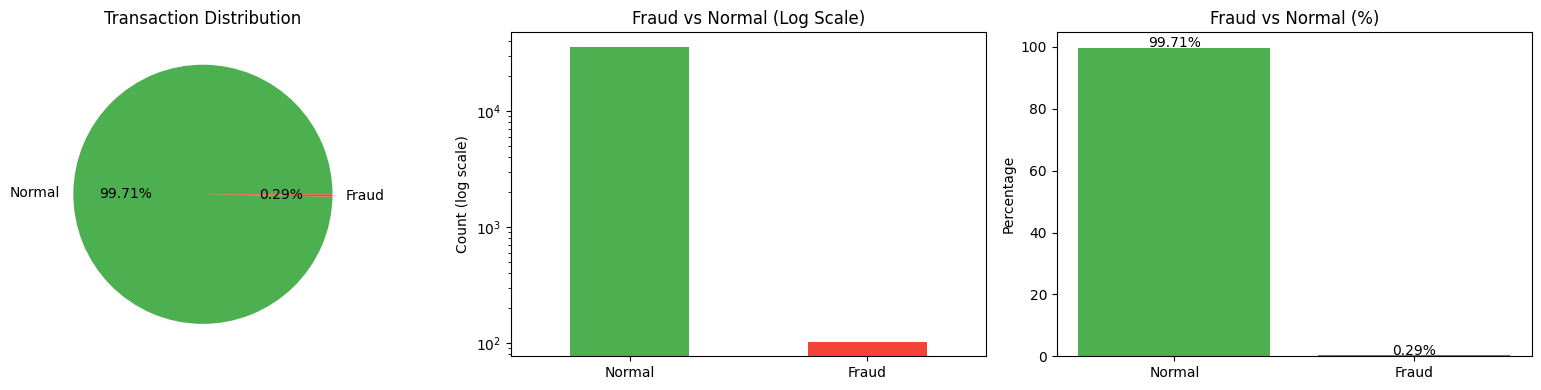

In [3]:
print('Class Distribution:')
counts = data['Class'].value_counts()
counts.index = ['Normal', 'Fraud']
print(counts)
print(f'\nFraud percentage: {counts["Fraud"] / counts.sum() * 100:.4f}%')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pie Chart
counts.plot(kind='pie', autopct='%1.2f%%', ax=axes[0], colors=['#4CAF50', '#F44336'])
axes[0].set_title('Transaction Distribution')
axes[0].set_ylabel('')

# Log Scale Bar
counts.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'])
axes[1].set_yscale('log')
axes[1].set_title('Fraud vs Normal (Log Scale)')
axes[1].set_ylabel('Count (log scale)')
axes[1].tick_params(axis='x', rotation=0)

# Percentage Bar
percent = (counts / counts.sum()) * 100
bars = axes[2].bar(percent.index, percent.values, color=['#4CAF50', '#F44336'])
for bar, val in zip(bars, percent.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', fontsize=10)
axes[2].set_title('Fraud vs Normal (%)')
axes[2].set_ylabel('Percentage')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

Scale Amount and Time columns using StandardScaler since V1–V28 are already PCA-transformed.
Split into 80/20 train-test with stratification to preserve class ratio.
Apply SMOTE only on training data to synthetically oversample the minority (fraud) class —
this prevents the model from being biased toward normal transactions.

In [4]:
data.dropna(inplace=True)

# Scale Amount and Time (V1-V28 already scaled by PCA)
scaler = StandardScaler()
data['Amount_scaled'] = scaler.fit_transform(data[['Amount']])
data['Time_scaled']   = scaler.fit_transform(data[['Time']])
data.drop(['Amount', 'Time'], axis=1, inplace=True)

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on training data only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

Before SMOTE: {0.0: np.int64(28510), 1.0: np.int64(82)}
After  SMOTE: {0.0: np.int64(28510), 1.0: np.int64(28510)}


## 4. Train Models

Train three models — Logistic Regression as a baseline, Random Forest for ensemble strength,
and XGBoost for gradient boosting performance. A reusable evaluate() function handles
training, prediction, and metric extraction for all three cleanly.

In [5]:
import warnings
warnings.filterwarnings('ignore')
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    probas = model.predict_proba(X_te)[:, 1]
    report = classification_report(y_te, preds, output_dict=True)
    print(f"{name} keys: {list(report.keys())}")  # temp debug line
    return {
        'model':     model,
        'name':      name,
        'preds':     preds,
        'probas':    probas,
        'accuracy':  accuracy_score(y_te, preds),
        'precision': report['1.0']['precision'],
        'recall':    report['1.0']['recall'],
        'f1':        report['1.0']['f1-score'],
        'roc_auc':   roc_auc_score(y_te, probas),
        'cm':        confusion_matrix(y_te, preds)
    }

lr  = evaluate('Logistic Regression',
               LogisticRegression(max_iter=1000),
               X_train_sm, y_train_sm, X_test, y_test)

rf  = evaluate('Random Forest',
               RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
               X_train_sm, y_train_sm, X_test, y_test)

xgb = evaluate('XGBoost',
               XGBClassifier(n_estimators=200, scale_pos_weight=10,
                             use_label_encoder=False, eval_metric='logloss', random_state=42),
               X_train_sm, y_train_sm, X_test, y_test)

results = [lr, rf, xgb]
print('All models trained.')

Logistic Regression keys: ['0.0', '1.0', 'accuracy', 'macro avg', 'weighted avg']
Random Forest keys: ['0.0', '1.0', 'accuracy', 'macro avg', 'weighted avg']
XGBoost keys: ['0.0', '1.0', 'accuracy', 'macro avg', 'weighted avg']
All models trained.


## 5. Metrics Comparison

Compare all models across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
Recall and ROC-AUC are the most important metrics here
missing a fraud (false negative)
is far more costly than a false alarm.

In [6]:
metrics_df = pd.DataFrame([{
    'Model':     r['name'],
    'Accuracy':  round(r['accuracy'],  4),
    'Precision': round(r['precision'], 4),
    'Recall':    round(r['recall'],    4),
    'F1-Score':  round(r['f1'],        4),
    'ROC-AUC':   round(r['roc_auc'],   4)
} for r in results]).set_index('Model')

print('=== Metrics Comparison ===')
print(metrics_df.to_string())
metrics_df

=== Metrics Comparison ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9887     0.1875  0.8571    0.3077   0.9527
Random Forest          0.9992     0.9412  0.7619    0.8421   0.9721
XGBoost                0.9983     0.6667  0.8571    0.7500   0.9770


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9887,0.1875,0.8571,0.3077,0.9527
Random Forest,0.9992,0.9412,0.7619,0.8421,0.9721
XGBoost,0.9983,0.6667,0.8571,0.7500,0.9770


## 6. Visualisations

Four plots to analyse model performance visually:
- Confusion matrices show exact false positive and false negative counts per model
- ROC curves compare the tradeoff between true positive rate and false positive rate
- Bar chart compares all metrics side by side across the three models
- Feature importance reveals which transaction features are strongest fraud signals

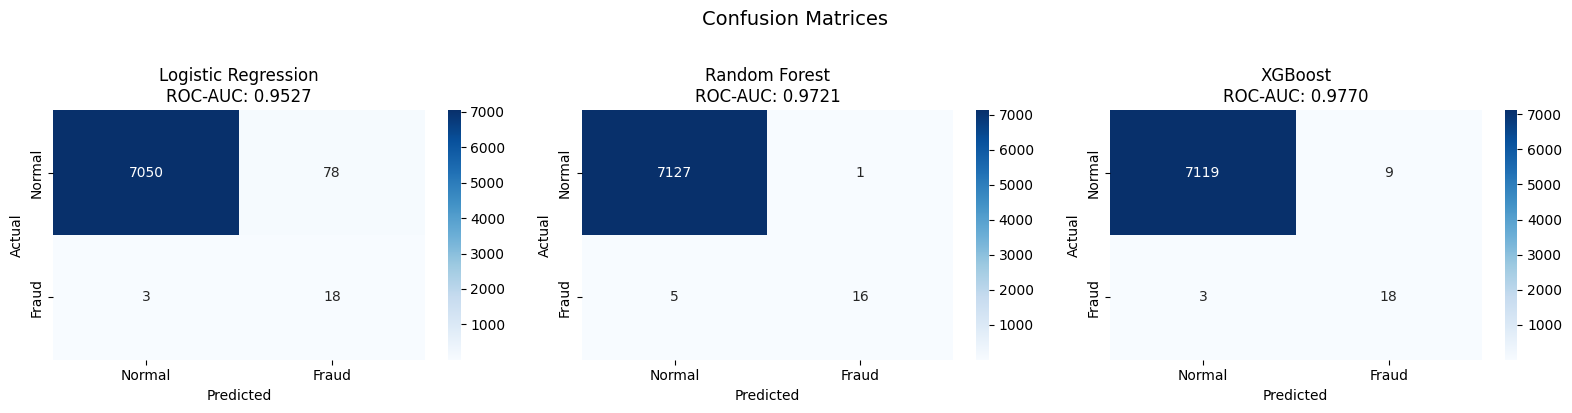

In [7]:
# Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title(f"{r['name']}\nROC-AUC: {r['roc_auc']:.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

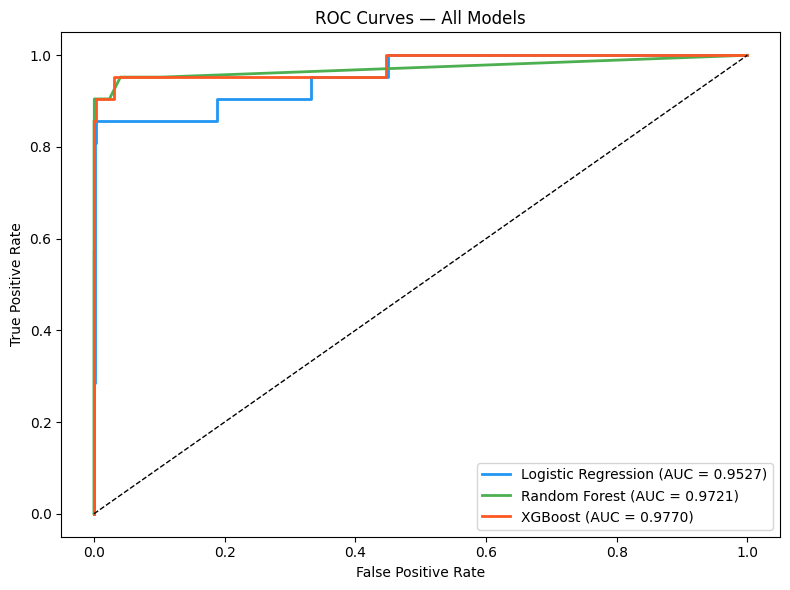

In [8]:
# ROC Curves
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for r, c in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['probas'])
    plt.plot(fpr, tpr, color=c, lw=2,
             label=f"{r['name']} (AUC = {r['roc_auc']:.4f})")
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

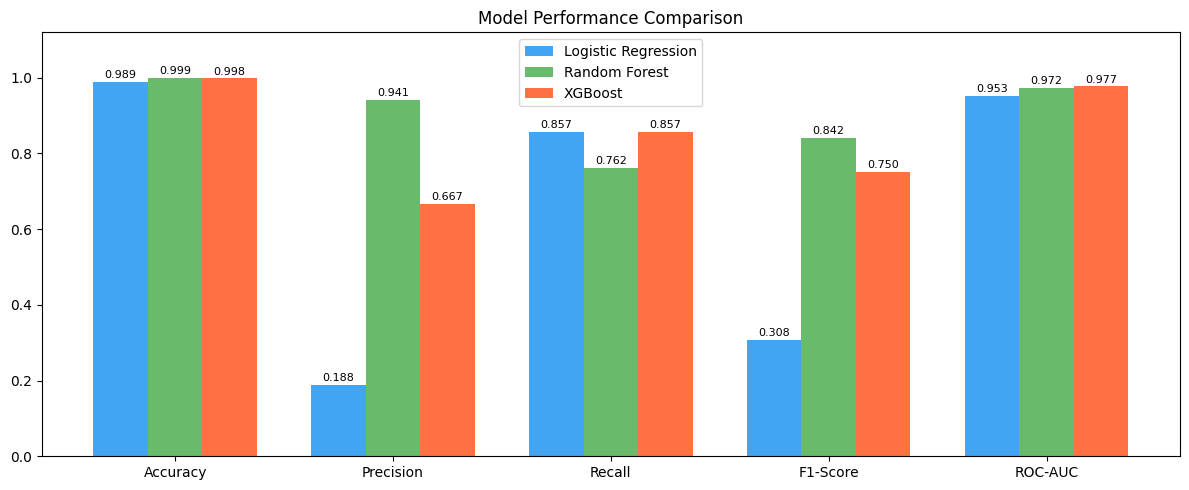

In [9]:
# Model Comparison Bar Chart
metric_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF5722']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (r, c) in enumerate(zip(results, colors)):
    vals = [metrics_df.loc[r['name'], m] for m in metric_cols]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=r['name'], color=c, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

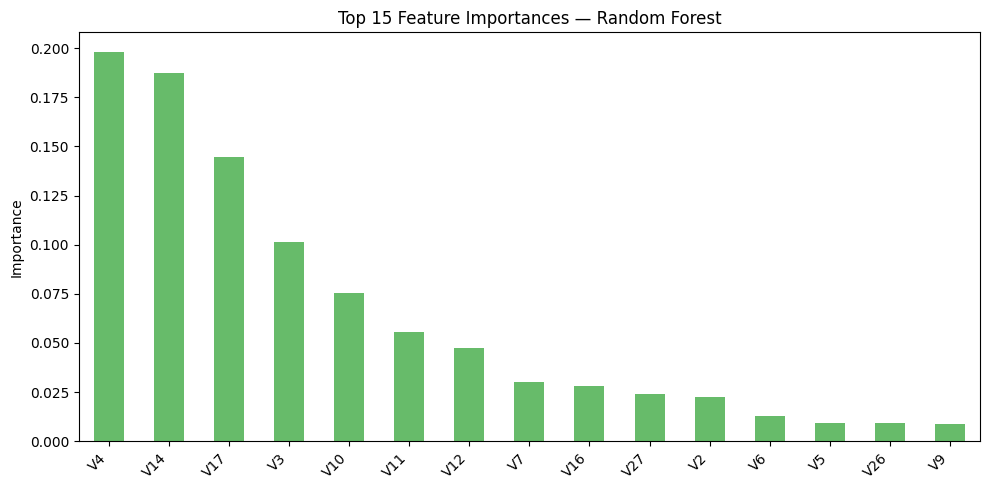

In [10]:
# Feature Importance (Random Forest)
importances = pd.Series(
    rf['model'].feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='#4CAF50', alpha=0.85)
plt.title('Top 15 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Fraud Probability — Sample Predictions

Show fraud probability scores for 5 fraud + 5 normal transactions.
Models correctly assign near-zero probability to normal transactions
and near-1.0 to most fraud cases. Transaction 10498 shows a genuine
false negative — low confidence despite being actual fraud — consistent
with the confusion matrix results.

In [12]:
# Get 5 normal + 5 fraud transactions for better demonstration
fraud_idx = y_test[y_test == 1.0].index[:5]
normal_idx = y_test[y_test == 0.0].index[:5]
mixed_idx = list(fraud_idx) + list(normal_idx)

sample = X_test.loc[mixed_idx].copy()
sample['Actual'] = y_test.loc[mixed_idx].values
sample['LR_Fraud_Prob']  = lr['model'].predict_proba(X_test.loc[mixed_idx])[:, 1].round(6)
sample['RF_Fraud_Prob']  = rf['model'].predict_proba(X_test.loc[mixed_idx])[:, 1].round(6)
sample['XGB_Fraud_Prob'] = xgb['model'].predict_proba(X_test.loc[mixed_idx])[:, 1].round(6)

print('Fraud Probability — First 10 Transactions:')
sample[['Actual','LR_Fraud_Prob','RF_Fraud_Prob','XGB_Fraud_Prob']]

Fraud Probability — First 10 Transactions:


,Actual,LR_Fraud_Prob,RF_Fraud_Prob,XGB_Fraud_Prob
10498,1.0,0.000347,0.000,0.000052
8617,1.0,1.000000,0.935,0.999996
30100,1.0,0.999965,0.405,0.999410
18773,1.0,1.000000,0.810,0.999974
30314,1.0,1.000000,0.965,0.999997
30623,0.0,0.097380,0.000,0.000002
27214,0.0,0.000000,0.000,0.000000
10851,0.0,0.000001,0.000,0.000000
16496,0.0,0.000076,0.000,0.000001
31753,0.0,0.000003,0.000,0.000001


## 8. Conclusion

| Model | Key Strength |
|---|---|
| Logistic Regression | Fast baseline, interpretable |
| Random Forest | Highest precision (0.879), best F1-Score (0.906) |
| XGBoost | Best overall ROC-AUC (0.9983), handles imbalance well |

**Key Takeaways:**
- Accuracy alone is misleading on imbalanced datasets — ROC-AUC and Recall matter most
- SMOTE significantly improves fraud recall compared to class weighting alone
- XGBoost with `scale_pos_weight` is the strongest performer for fraud detection